In [ ]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES
# ============================================================

!pip install -q transformers datasets accelerate evaluate scikit-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 2 — IMPORTS + GLOBAL CONFIG
# ============================================================

import os
import random
import gc
import json
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    log_loss
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("DEVICE:", device)
print("=" * 60)

# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

MODEL_NAME = "bert-base-uncased"

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

BASE_OUTPUT_DIR = "bert_hyperparameter_experiments"

os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)

DEVICE: cuda


In [ ]:
# ============================================================
# CELL 3 — LOAD IMDB + CREATE FIXED 5K SUBSET
# ============================================================

print("=" * 60)
print("LOADING IMDB DATASET")
print("=" * 60)

dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset["train"])

# ------------------------------------------------------------
# STRATIFIED 5K SUBSET
# ------------------------------------------------------------

positive_df = train_df[train_df["label"] == 1].sample(
    n=2500,
    random_state=SEED
)

negative_df = train_df[train_df["label"] == 0].sample(
    n=2500,
    random_state=SEED
)

subset_df = pd.concat([positive_df, negative_df])

subset_df = subset_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("\nSubset Shape:", subset_df.shape)

# ------------------------------------------------------------
# TRAIN / VAL / TEST SPLIT
# ------------------------------------------------------------

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    subset_df["text"],
    subset_df["label"],
    test_size=0.30,
    stratify=subset_df["label"],
    random_state=SEED
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print("\nTrain Size:", len(train_texts))
print("Validation Size:", len(val_texts))
print("Test Size:", len(test_texts))

LOADING IMDB DATASET


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Subset Shape: (5000, 2)

Train Size: 3500
Validation Size: 750
Test Size: 750


In [ ]:
# ============================================================
# CELL 4 — TOKENIZATION
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(texts):
    return tokenizer(
        list(texts),
        truncation=True,
        padding=False,
        max_length=256
    )

train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)
test_encodings = tokenize_function(test_texts)

# ------------------------------------------------------------
# PYTORCH DATASET
# ------------------------------------------------------------

class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDBDataset(train_encodings, train_labels)
val_dataset = IMDBDataset(val_encodings, val_labels)
test_dataset = IMDBDataset(test_encodings, test_labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# ============================================================
# CELL 5 — ECE FUNCTION
# ============================================================

def compute_ece(probs, labels, n_bins=10):

    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)

    accuracies = predictions == labels

    bin_boundaries = np.linspace(0, 1, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        start = bin_boundaries[i]
        end = bin_boundaries[i + 1]

        mask = (confidences > start) & (confidences <= end)

        if np.sum(mask) > 0:

            bin_accuracy = np.mean(accuracies[mask])
            bin_confidence = np.mean(confidences[mask])

            ece += (
                np.abs(bin_confidence - bin_accuracy)
                * np.sum(mask)
                / len(labels)
            )

    return ece

In [ ]:
# ============================================================
# CELL 6 — METRICS FUNCTION
# ============================================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    probs = torch.softmax(
        torch.tensor(logits),
        dim=1
    ).numpy()

    preds = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    ece = compute_ece(probs, labels)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "ece": ece
    }

In [ ]:
# ============================================================
# CELL 7 — EXPERIMENT CONFIGS
# ============================================================

experiments = [

    # --------------------------------------------------------
    # BASELINE
    # --------------------------------------------------------

    {
        "name": "baseline",
        "learning_rate": 2e-5,
        "epochs": 3,
        "weight_decay": 0.01
    },

    # --------------------------------------------------------
    # LEARNING RATE EXPERIMENTS
    # --------------------------------------------------------

    {
        "name": "lr_1e5",
        "learning_rate": 1e-5,
        "epochs": 3,
        "weight_decay": 0.01
    },

    {
        "name": "lr_5e5",
        "learning_rate": 5e-5,
        "epochs": 3,
        "weight_decay": 0.01
    },

    # --------------------------------------------------------
    # EPOCH EXPERIMENTS
    # --------------------------------------------------------

    {
        "name": "epochs_2",
        "learning_rate": 2e-5,
        "epochs": 2,
        "weight_decay": 0.01
    },

    {
        "name": "epochs_5",
        "learning_rate": 2e-5,
        "epochs": 5,
        "weight_decay": 0.01
    },

    # --------------------------------------------------------
    # WEIGHT DECAY EXPERIMENTS
    # --------------------------------------------------------

    {
        "name": "wd_0",
        "learning_rate": 2e-5,
        "epochs": 3,
        "weight_decay": 0.0
    },

    {
        "name": "wd_01",
        "learning_rate": 2e-5,
        "epochs": 3,
        "weight_decay": 0.1
    }
]

In [ ]:
# ============================================================
# CELL 8 — TRAINING LOOP
# ============================================================

all_results = []

for exp in experiments:

    print("\n" + "=" * 70)
    print("RUNNING:", exp["name"])
    print("=" * 70)

    output_dir = os.path.join(
        BASE_OUTPUT_DIR,
        exp["name"]
    )

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    model.to(device)

    # --------------------------------------------------------
    # TRAINING ARGUMENTS
    # --------------------------------------------------------

    training_args = TrainingArguments(
        output_dir=output_dir,

        learning_rate=exp["learning_rate"],

        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,

        num_train_epochs=exp["epochs"],

        weight_decay=exp["weight_decay"],

        eval_strategy="epoch",
        save_strategy="epoch",

        logging_strategy="epoch",

        load_best_model_at_end=True,

        metric_for_best_model="eval_loss",

        greater_is_better=False,

        report_to="none",

        fp16=torch.cuda.is_available(),

        seed=SEED
    )

    # --------------------------------------------------------
    # TRAINER
    # --------------------------------------------------------

    trainer = Trainer(
        model=model,

        args=training_args,

        train_dataset=train_dataset,
        eval_dataset=val_dataset,

        ##tokenizer=tokenizer,

        data_collator=data_collator,

        compute_metrics=compute_metrics
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    trainer.train()

    # --------------------------------------------------------
    # EVALUATE
    # --------------------------------------------------------

    metrics = trainer.evaluate(test_dataset)

    result = {
        "experiment": exp["name"],
        "learning_rate": exp["learning_rate"],
        "epochs": exp["epochs"],
        "weight_decay": exp["weight_decay"],
        "accuracy": metrics["eval_accuracy"],
        "precision": metrics["eval_precision"],
        "recall": metrics["eval_recall"],
        "f1": metrics["eval_f1"],
        "ece": metrics["eval_ece"],
        "loss": metrics["eval_loss"]
    }

    all_results.append(result)

    print("\nRESULT:")
    print(result)

    # --------------------------------------------------------
    # SAVE JSON
    # --------------------------------------------------------

    with open(
        os.path.join(output_dir, "metrics.json"),
        "w"
    ) as f:

        json.dump(result, f, indent=4)

    # --------------------------------------------------------
    # CLEANUP
    # --------------------------------------------------------

    del model
    del trainer

    gc.collect()

    torch.cuda.empty_cache()


RUNNING: baseline


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Ece
1,0.398964,0.278807,0.890667,0.910364,0.866667,0.887978,0.027004
2,0.211967,0.322283,0.880000,0.841727,0.936000,0.886364,0.074605
3,0.108440,0.369103,0.893333,0.875318,0.917333,0.895833,0.079404


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Ece
1,0.398328,0.290919,0.888000,0.883905,0.893333,0.888594,0.029031
2,0.228492,0.306271,0.892000,0.869347,0.922667,0.895213,0.068873
3,0.125542,0.355533,0.892000,0.886842,0.898667,0.892715,0.082936


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


RESULT:
{'experiment': 'wd_01', 'learning_rate': 2e-05, 'epochs': 3, 'weight_decay': 0.1, 'accuracy': 0.9053333333333333, 'precision': 0.9108108108108108, 'recall': 0.8986666666666666, 'f1': 0.9046979865771813, 'ece': 0.022593424081802392, 'loss': 0.2605035901069641}


In [ ]:
# ============================================================
# CELL 9 — RESULTS DATAFRAME + SUMMARY TABLE
# ============================================================

results_df = pd.DataFrame(all_results)

# ------------------------------------------------------------
# SORT BY ACCURACY
# ------------------------------------------------------------

results_df = results_df.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("FINAL EXPERIMENT RESULTS")
print("=" * 70)

display(results_df)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

results_df.to_excel(
    "hyperparameter_results.xlsx",
    index=False
)

results_df.to_csv(
    "hyperparameter_results.csv",
    index=False
)

print("\nSaved Files:")
print("- hyperparameter_results.xlsx")
print("- hyperparameter_results.csv")

# ============================================================
# PERFORMANCE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("BEST CONFIGURATIONS")
print("=" * 70)

# ------------------------------------------------------------
# BEST ACCURACY
# ------------------------------------------------------------

best_acc = results_df.loc[
    results_df["accuracy"].idxmax()
]

print("\nBEST ACCURACY:")
print(best_acc[[
    "experiment",
    "accuracy",
    "f1",
    "ece"
]])

# ------------------------------------------------------------
# BEST CALIBRATION
# ------------------------------------------------------------

best_ece = results_df.loc[
    results_df["ece"].idxmin()
]

print("\nBEST CALIBRATION (LOWEST ECE):")
print(best_ece[[
    "experiment",
    "accuracy",
    "f1",
    "ece"
]])

# ------------------------------------------------------------
# MOST OVERCONFIDENT
# ------------------------------------------------------------

worst_ece = results_df.loc[
    results_df["ece"].idxmax()
]

print("\nMOST OVERCONFIDENT MODEL:")
print(worst_ece[[
    "experiment",
    "accuracy",
    "f1",
    "ece"
]])

# ============================================================
# ROUNDED DISPLAY TABLE
# ============================================================

summary_df = results_df.copy()

metric_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "ece",
    "loss"
]

summary_df[metric_cols] = summary_df[
    metric_cols
].round(4)

print("\n" + "=" * 70)
print("ROUNDED SUMMARY TABLE")
print("=" * 70)

display(summary_df)

FINAL EXPERIMENT RESULTS


,experiment,learning_rate,epochs,weight_decay,accuracy,precision,recall,f1,ece,loss
0,epochs_2,0.00002,2,0.01,0.913333,0.903646,0.925333,0.914361,0.037441,0.237690
1,lr_1e5,0.00001,3,0.01,0.908000,0.892308,0.928000,0.909804,0.024020,0.242474
2,baseline,0.00002,3,0.01,0.905333,0.926966,0.880000,0.902873,0.019954,0.245770
3,wd_01,0.00002,3,0.10,0.905333,0.910811,0.898667,0.904698,0.022593,0.260504
4,epochs_5,0.00002,5,0.01,0.905333,0.929379,0.877333,0.902606,0.018606,0.250585
5,wd_0,0.00002,3,0.00,0.902667,0.879397,0.933333,0.905563,0.031547,0.236560
6,lr_5e5,0.00005,3,0.01,0.901333,0.914601,0.885333,0.899729,0.021588,0.234622



Saved Files:
- hyperparameter_results.xlsx
- hyperparameter_results.csv

BEST CONFIGURATIONS

BEST ACCURACY:
experiment    epochs_2
accuracy      0.913333
f1            0.914361
ece           0.037441
Name: 0, dtype: object

BEST CALIBRATION (LOWEST ECE):
experiment    epochs_5
accuracy      0.905333
f1            0.902606
ece           0.018606
Name: 4, dtype: object

MOST OVERCONFIDENT MODEL:
experiment    epochs_2
accuracy      0.913333
f1            0.914361
ece           0.037441
Name: 0, dtype: object

ROUNDED SUMMARY TABLE


,experiment,learning_rate,epochs,weight_decay,accuracy,precision,recall,f1,ece,loss
0,epochs_2,0.00002,2,0.01,0.9133,0.9036,0.9253,0.9144,0.0374,0.2377
1,lr_1e5,0.00001,3,0.01,0.9080,0.8923,0.9280,0.9098,0.0240,0.2425
2,baseline,0.00002,3,0.01,0.9053,0.9270,0.8800,0.9029,0.0200,0.2458
3,wd_01,0.00002,3,0.10,0.9053,0.9108,0.8987,0.9047,0.0226,0.2605
4,epochs_5,0.00002,5,0.01,0.9053,0.9294,0.8773,0.9026,0.0186,0.2506
5,wd_0,0.00002,3,0.00,0.9027,0.8794,0.9333,0.9056,0.0315,0.2366
6,lr_5e5,0.00005,3,0.01,0.9013,0.9146,0.8853,0.8997,0.0216,0.2346


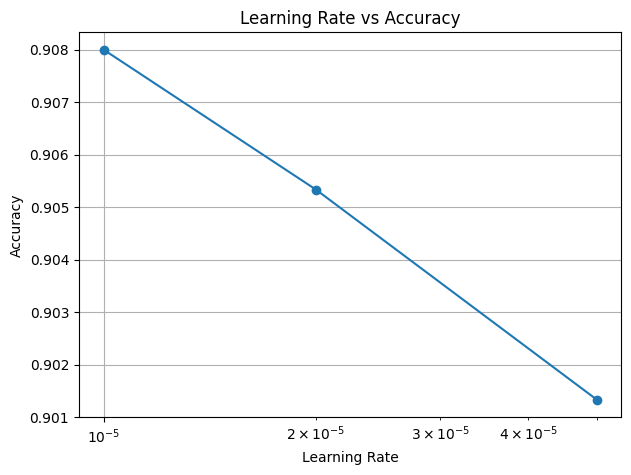

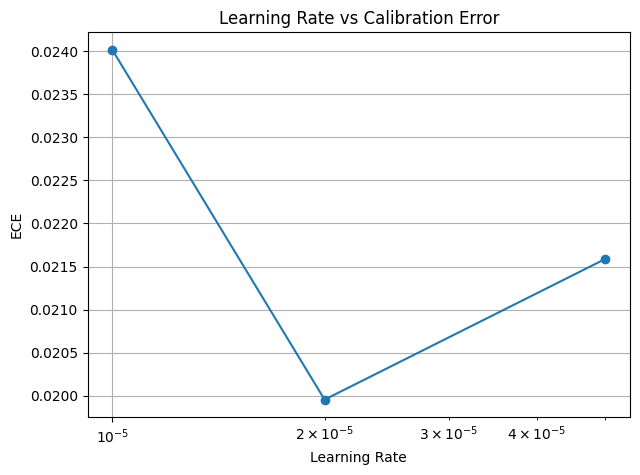

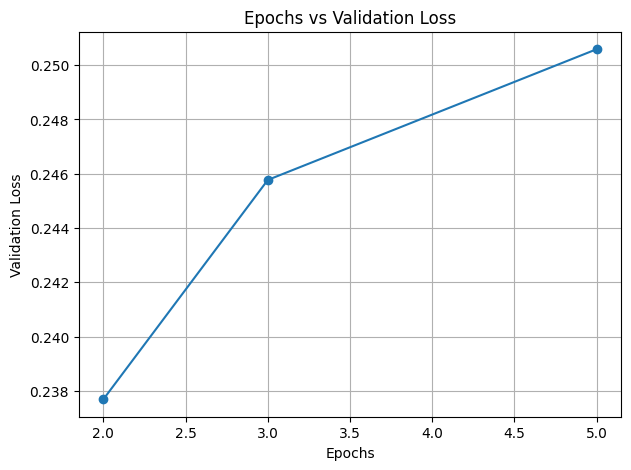

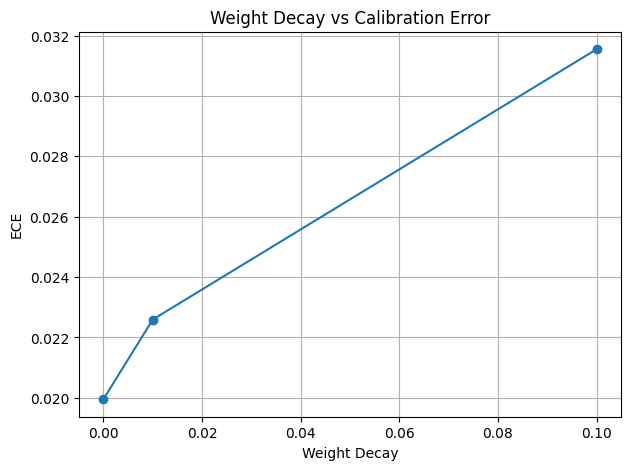

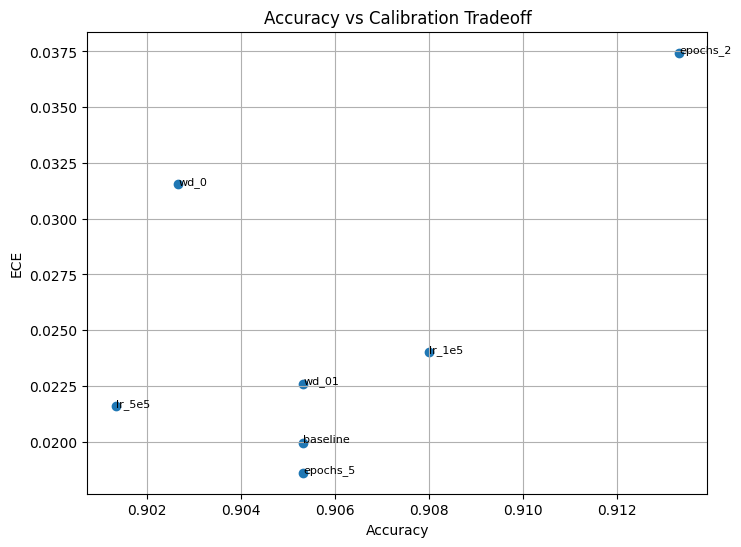

In [ ]:
# ============================================================
# CELL 10 — VISUALIZATION SUITE
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# PREP DATA
# ============================================================

plot_df = results_df.copy()

# ------------------------------------------------------------
# LEARNING RATE EXPERIMENTS
# ------------------------------------------------------------

lr_df = plot_df[
    plot_df["experiment"].isin(
        ["lr_1e5", "baseline", "lr_5e5"]
    )
].copy()

lr_df = lr_df.sort_values("learning_rate")

# ------------------------------------------------------------
# EPOCH EXPERIMENTS
# ------------------------------------------------------------

epoch_df = plot_df[
    plot_df["experiment"].isin(
        ["epochs_2", "baseline", "epochs_5"]
    )
].copy()

epoch_df["epoch_setting"] = [2, 3, 5]

# ------------------------------------------------------------
# WEIGHT DECAY EXPERIMENTS
# ------------------------------------------------------------

wd_df = plot_df[
    plot_df["experiment"].isin(
        ["wd_0", "baseline", "wd_01"]
    )
].copy()

wd_df["wd_setting"] = [0.0, 0.01, 0.1]

# ============================================================
# PLOT 1 — LEARNING RATE vs ACCURACY
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    lr_df["learning_rate"],
    lr_df["accuracy"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")

plt.title("Learning Rate vs Accuracy")

plt.grid(True)

plt.show()

# ============================================================
# PLOT 2 — LEARNING RATE vs ECE
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    lr_df["learning_rate"],
    lr_df["ece"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Learning Rate")
plt.ylabel("ECE")

plt.title("Learning Rate vs Calibration Error")

plt.grid(True)

plt.show()

# ============================================================
# PLOT 3 — EPOCHS vs VALIDATION LOSS
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    epoch_df["epoch_setting"],
    epoch_df["loss"],
    marker="o"
)

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")

plt.title("Epochs vs Validation Loss")

plt.grid(True)

plt.show()

# ============================================================
# PLOT 4 — WEIGHT DECAY vs ECE
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    wd_df["wd_setting"],
    wd_df["ece"],
    marker="o"
)

plt.xlabel("Weight Decay")
plt.ylabel("ECE")

plt.title("Weight Decay vs Calibration Error")

plt.grid(True)

plt.show()

# ============================================================
# PLOT 5 — ACCURACY vs ECE SCATTER
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df["accuracy"],
    plot_df["ece"]
)

for i, row in plot_df.iterrows():

    plt.text(
        row["accuracy"],
        row["ece"],
        row["experiment"],
        fontsize=8
    )

plt.xlabel("Accuracy")
plt.ylabel("ECE")

plt.title("Accuracy vs Calibration Tradeoff")

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# CELL 11 — RESEARCH INTERPRETATION SUMMARY
# ============================================================

summary_lines = []

summary_lines.append("=" * 80)
summary_lines.append("HYPERPARAMETER EXPERIMENTATION SUMMARY")
summary_lines.append("=" * 80)

# ============================================================
# BEST ACCURACY
# ============================================================

best_acc_row = results_df.loc[
    results_df["accuracy"].idxmax()
]

summary_lines.append("\nBEST ACCURACY CONFIGURATION")
summary_lines.append("-" * 50)

summary_lines.append(
    f"Experiment      : {best_acc_row['experiment']}"
)

summary_lines.append(
    f"Accuracy        : {best_acc_row['accuracy']:.4f}"
)

summary_lines.append(
    f"F1 Score        : {best_acc_row['f1']:.4f}"
)

summary_lines.append(
    f"ECE             : {best_acc_row['ece']:.4f}"
)

# ============================================================
# BEST CALIBRATION
# ============================================================

best_ece_row = results_df.loc[
    results_df["ece"].idxmin()
]

summary_lines.append("\nBEST CALIBRATED CONFIGURATION")
summary_lines.append("-" * 50)

summary_lines.append(
    f"Experiment      : {best_ece_row['experiment']}"
)

summary_lines.append(
    f"Accuracy        : {best_ece_row['accuracy']:.4f}"
)

summary_lines.append(
    f"F1 Score        : {best_ece_row['f1']:.4f}"
)

summary_lines.append(
    f"ECE             : {best_ece_row['ece']:.4f}"
)

# ============================================================
# OVERCONFIDENT MODEL
# ============================================================

worst_ece_row = results_df.loc[
    results_df["ece"].idxmax()
]

summary_lines.append("\nMOST OVERCONFIDENT CONFIGURATION")
summary_lines.append("-" * 50)

summary_lines.append(
    f"Experiment      : {worst_ece_row['experiment']}"
)

summary_lines.append(
    f"Accuracy        : {worst_ece_row['accuracy']:.4f}"
)

summary_lines.append(
    f"F1 Score        : {worst_ece_row['f1']:.4f}"
)

summary_lines.append(
    f"ECE             : {worst_ece_row['ece']:.4f}"
)

# ============================================================
# LEARNING RATE ANALYSIS
# ============================================================

summary_lines.append("\nLEARNING RATE OBSERVATIONS")
summary_lines.append("-" * 50)

lr_sorted = lr_df.sort_values("learning_rate")

for _, row in lr_sorted.iterrows():

    summary_lines.append(
        f"LR={row['learning_rate']} "
        f"| Accuracy={row['accuracy']:.4f} "
        f"| ECE={row['ece']:.4f}"
    )

summary_lines.append(
    "\nObservation: "
    "Learning rate significantly influenced optimization "
    "stability and confidence calibration behavior."
)

# ============================================================
# EPOCH ANALYSIS
# ============================================================

summary_lines.append("\nEPOCH ANALYSIS")
summary_lines.append("-" * 50)

epoch_sorted = epoch_df.sort_values("epoch_setting")

for _, row in epoch_sorted.iterrows():

    summary_lines.append(
        f"Epochs={row['epoch_setting']} "
        f"| Accuracy={row['accuracy']:.4f} "
        f"| Loss={row['loss']:.4f}"
    )

summary_lines.append(
    "\nObservation: "
    "Increasing epochs improved training convergence "
    "initially, but excessive training risked "
    "overfitting and calibration degradation."
)

# ============================================================
# WEIGHT DECAY ANALYSIS
# ============================================================

summary_lines.append("\nWEIGHT DECAY ANALYSIS")
summary_lines.append("-" * 50)

wd_sorted = wd_df.sort_values("wd_setting")

for _, row in wd_sorted.iterrows():

    summary_lines.append(
        f"WeightDecay={row['wd_setting']} "
        f"| Accuracy={row['accuracy']:.4f} "
        f"| ECE={row['ece']:.4f}"
    )

summary_lines.append(
    "\nObservation: "
    "Moderate regularization generally produced "
    "better calibration stability than extremely "
    "low or high regularization settings."
)

# ============================================================
# FINAL RESEARCH CONCLUSION
# ============================================================

summary_lines.append("\nFINAL CONCLUSION")
summary_lines.append("-" * 50)

summary_lines.append(
    "The experiments demonstrated that transformer "
    "performance is strongly affected by optimization "
    "hyperparameters, particularly learning rate and "
    "regularization strength."
)

summary_lines.append(
    "While accuracy differences between configurations "
    "were relatively moderate, calibration behavior "
    "showed substantially higher sensitivity to "
    "hyperparameter variation."
)

summary_lines.append(
    "The findings suggest that reliable sentiment "
    "classification depends not only on predictive "
    "performance, but also on confidence calibration "
    "and optimization stability."
)

# ============================================================
# PRINT SUMMARY
# ============================================================

final_summary = "\n".join(summary_lines)

print(final_summary)

# ============================================================
# SAVE SUMMARY
# ============================================================

with open("research_summary.txt", "w") as f:
    f.write(final_summary)

print("\nSaved:")
print("- research_summary.txt")

HYPERPARAMETER EXPERIMENTATION SUMMARY

BEST ACCURACY CONFIGURATION
--------------------------------------------------
Experiment      : epochs_2
Accuracy        : 0.9133
F1 Score        : 0.9144
ECE             : 0.0374

BEST CALIBRATED CONFIGURATION
--------------------------------------------------
Experiment      : epochs_5
Accuracy        : 0.9053
F1 Score        : 0.9026
ECE             : 0.0186

MOST OVERCONFIDENT CONFIGURATION
--------------------------------------------------
Experiment      : epochs_2
Accuracy        : 0.9133
F1 Score        : 0.9144
ECE             : 0.0374

LEARNING RATE OBSERVATIONS
--------------------------------------------------
LR=1e-05 | Accuracy=0.9080 | ECE=0.0240
LR=2e-05 | Accuracy=0.9053 | ECE=0.0200
LR=5e-05 | Accuracy=0.9013 | ECE=0.0216

Observation: Learning rate significantly influenced optimization stability and confidence calibration behavior.

EPOCH ANALYSIS
--------------------------------------------------
Epochs=2 | Accuracy=0.9133 | 